1. Introduction — Context

This dataset contains information about popular Spotify songs from the late 1990s and early 2000s. Each row represents one song and includes details about the artist, song title, release year, popularity, genre, and several audio features such as danceability, energy, tempo, loudness, and acousticness.

The data appears to come from Spotify’s music database or Spotify API, which provides both song metadata and audio analysis generated through machine learning algorithms. These audio features describe characteristics of the music and are commonly used in music recommendation systems and streaming analysis.

The dataset was likely collected by selecting well-known or trending songs from a specific time period and retrieving their attributes from Spotify. Because of this, the dataset may not represent all songs released during those years, but rather a subset of commercially successful or recognizable tracks.

The population represented in this dataset is mainly mainstream popular music artists and songs, especially from genres such as pop, rock, hip hop, R&B, metal, and electronic dance music. Therefore, conclusions drawn from the dataset should be limited to these types of songs and may not apply to less popular, independent, or non-Spotify music.

In [2]:
!pip install plotly


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\nehaa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode
import seaborn as sns


LOAD DATA set

In [7]:
df=pd.read_csv("C://Users//nehaa//Downloads//songs_normalize.csv")

2. Loading and Mechanical Inspection

The dataset was loaded into a DataFrame for inspection and basic exploration. After loading the data, methods such as .shape, .info(), and .describe() can be used to understand its structure and quality.

Dataset Size

Using .shape shows the number of rows and columns in the dataset.

Rows represent individual Spotify songs.
Columns represent song attributes such as artist name, popularity, genre, and audio features.

The dataset contains multiple columns describing both categorical and numerical information about songs.

Column Overview and Data Types

Using .info() provides details about:

Column names
Data types
Number of non-null values

The dataset includes:

Categorical columns such as:
artist
song
genre
explicit
Numerical columns such as:
duration_ms
year
popularity
danceability
energy
tempo
loudness
acousticness

Most numerical columns are stored as integers or floating-point numbers, while text-based columns are stored as objects (strings). The explicit column is a Boolean variable indicating whether the song contains explicit content.

Statistical Summary

Using .describe() generates summary statistics for numerical variables, including:

Mean
Standard deviation
Minimum and maximum values
Quartiles

This helps identify:

Average song popularity
Typical song duration
Distribution of audio features such as danceability and energy
Possible outliers or unusual values

For example:

danceability and energy values range between 0 and 1.
duration_ms shows variation in song lengths.
tempo indicates differences in beats per minute across songs.
Missing Values

Missing values can be checked using .isnull().sum().

In this dataset, there appear to be very few or no missing values in most columns. If missing values exist, they may occur because:

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            2000 non-null   object 
 1   song              2000 non-null   object 
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   year              2000 non-null   int64  
 5   popularity        2000 non-null   int64  
 6   danceability      2000 non-null   float64
 7   energy            2000 non-null   float64
 8   key               2000 non-null   int64  
 9   loudness          2000 non-null   float64
 10  mode              2000 non-null   int64  
 11  speechiness       2000 non-null   float64
 12  acousticness      2000 non-null   float64
 13  instrumentalness  2000 non-null   float64
 14  liveness          2000 non-null   float64
 15  valence           2000 non-null   float64
 16  tempo             2000 non-null   float64


In [9]:
df.head()

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,"rock, metal"
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop


1.artist: Name of the Artist.
2.song: Name of the Track.
3.duration_ms: Duration of the track in milliseconds.
4.explicit: The lyrics or content of a song or a music video contain one or more of the criteria which could be considered offensive or unsuitable for children.
5.year: Release Year of the track.
6.popularity: The higher the value the more popular the song is.
7.danceability: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable.
8.energy: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity.
9.key: The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1.
10.loudness: The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track and are useful for comparing relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typically range between -60 and 0 db.
11.mode: Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0.
12.speechiness: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks.
13.acousticness: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic.
14.instrumentalness: Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0.
15.liveness: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live.
16.valence: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry).
17.tempo: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration.
18.genre: Genre of the track.

In [10]:
df.isnull().sum()

artist              0
song                0
duration_ms         0
explicit            0
year                0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
genre               0
dtype: int64

There is no missing value but if we had we will do featurer engniring where we found we can calcuate that value we use mean, mediam , mode

In [11]:
df.artist

0       Britney Spears
1            blink-182
2           Faith Hill
3             Bon Jovi
4               *NSYNC
             ...      
1995    Jonas Brothers
1996      Taylor Swift
1997      Blanco Brown
1998         Sam Smith
1999       Post Malone
Name: artist, Length: 2000, dtype: object

it is name of artist it is test so we have to change categorical data to numercial data when we want to used in data set for that one hot encoding is methord we can used

In [12]:
df.popularity

0       77
1       79
2       66
3       78
4       65
        ..
1995    79
1996    78
1997    69
1998    75
1999    85
Name: popularity, Length: 2000, dtype: int64

it show popularity which is integer 

In [13]:
df.artist.value_counts()

artist
Rihanna                25
Drake                  23
Eminem                 21
Calvin Harris          20
Britney Spears         19
                       ..
Sam Feldt               1
Megan Thee Stallion     1
Dominic Fike            1
Ashley O                1
Tyler, The Creator      1
Name: count, Length: 835, dtype: int64

explore more data set to get more data

In [14]:
df.genre

0                    pop
1              rock, pop
2           pop, country
3            rock, metal
4                    pop
              ...       
1995                 pop
1996                 pop
1997    hip hop, country
1998                 pop
1999             hip hop
Name: genre, Length: 2000, dtype: object

genre is categorical data we can change it througe one hot encoding

In [15]:
df.genre.value_counts()

genre
pop                                      428
hip hop, pop                             277
hip hop, pop, R&B                        244
pop, Dance/Electronic                    221
pop, R&B                                 178
hip hop                                  124
hip hop, pop, Dance/Electronic            78
rock                                      58
rock, pop                                 43
Dance/Electronic                          41
rock, metal                               38
pop, latin                                28
pop, rock                                 26
set()                                     22
hip hop, Dance/Electronic                 16
latin                                     15
pop, rock, metal                          14
hip hop, pop, latin                       14
R&B                                       13
pop, rock, Dance/Electronic               13
country                                   10
hip hop, pop, rock                         9
meta

In [16]:
df["popularity"].max()

np.int64(89)

In [17]:
#most popular song
df[df["popularity"] == 89]

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
1322,The Neighbourhood,Sweater Weather,240400,False,2013,89,0.612,0.807,10,-2.81,1,0.0336,0.0495,0.0177,0.101,0.398,124.053,"rock, pop"


In [18]:
df["popularity"].min()

np.int64(0)

In [19]:
# least popular/unpopular song
df[df["popularity"] == 0]

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
59,Oasis,Go Let It Out,278666,False,2000,0,0.408,0.849,2,-5.631,1,0.0333,0.01360,0.000025,0.5600,0.628,84.192,"Folk/Acoustic, rock"
62,Mariah Carey,Against All Odds (Take A Look at Me Now) (feat...,199480,False,2011,0,0.471,0.514,1,-5.599,1,0.0315,0.58400,0.000000,0.1030,0.373,117.338,"pop, R&B"
126,Jennifer Lopez,Ain't It Funny,246160,False,2001,0,0.707,0.869,5,-4.525,0,0.0481,0.10400,0.000121,0.0813,0.621,99.825,"hip hop, pop, R&B"
175,DB Boulevard,Point Of View - Radio Edit,231166,False,2018,0,0.676,0.715,6,-6.854,1,0.0287,0.00284,0.074600,0.0685,0.275,129.006,Dance/Electronic
182,Musiq Soulchild,Love,304666,False,2000,0,0.569,0.385,1,-9.919,0,0.0499,0.34200,0.000000,0.0876,0.339,99.738,"pop, R&B"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1789,CNCO,Reggaetón Lento (Remix),188786,False,2017,0,0.623,0.909,4,-3.079,0,0.0758,0.15800,0.000000,0.0972,0.651,93.984,"pop, latin"
1794,Shawn Mendes,Mercy,208733,False,2017,0,0.561,0.674,4,-4.882,0,0.0818,0.11800,0.000000,0.1110,0.383,148.127,pop
1850,Loud Luxury,Body (feat. brando),163216,False,2017,0,0.752,0.764,1,-4.399,1,0.0380,0.04760,0.000094,0.0543,0.582,121.958,"pop, Dance/Electronic"
1913,NLE Choppa,Shotta Flow (feat. Blueface) [Remix],176631,True,2019,0,0.894,0.511,2,-4.768,1,0.4200,0.02510,0.000000,0.1400,0.568,120.080,hip hop


In [20]:
df["danceability"].max()

np.float64(0.975)

In [21]:
# most dansable song
df[df["danceability"] == 0.975]

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
714,Timbaland,Give It To Me,234026,True,2007,70,0.975,0.711,8,-3.904,1,0.0632,0.168,0.000552,0.0799,0.815,110.621,"hip hop, pop, R&B"


In [22]:
#top 10 popular songs
most_popular=df.sort_values("popularity",ascending=False).head(10)

In [23]:
most_popular

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
1322,The Neighbourhood,Sweater Weather,240400,False,2013,89,0.612,0.807,10,-2.810,1,0.0336,0.04950,0.017700,0.1010,0.398,124.053,"rock, pop"
1311,Tom Odell,Another Love,244360,True,2013,88,0.445,0.537,4,-8.532,0,0.0400,0.69500,0.000017,0.0944,0.131,122.769,pop
201,Eminem,Without Me,290320,True,2002,87,0.908,0.669,7,-2.827,1,0.0738,0.00286,0.000000,0.2370,0.662,112.238,hip hop
1929,Billie Eilish,lovely (with Khalid),200185,False,2018,86,0.351,0.296,4,-10.109,0,0.0333,0.93400,0.000000,0.0950,0.120,115.284,"pop, Dance/Electronic"
1613,WILLOW,Wait a Minute!,196520,False,2015,86,0.764,0.705,3,-5.279,0,0.0278,0.03710,0.000019,0.0943,0.672,101.003,"pop, R&B, Dance/Electronic"
1819,Billie Eilish,lovely (with Khalid),200185,False,2018,86,0.351,0.296,4,-10.109,0,0.0333,0.93400,0.000000,0.0950,0.120,115.284,"pop, Dance/Electronic"
6,Eminem,The Real Slim Shady,284200,True,2000,86,0.949,0.661,5,-4.244,0,0.0572,0.03020,0.000000,0.0454,0.760,104.504,hip hop
1512,The Neighbourhood,Daddy Issues,260173,False,2015,85,0.588,0.521,10,-9.461,1,0.0329,0.06780,0.149000,0.1230,0.337,85.012,"rock, pop"
1709,Ed Sheeran,Perfect,263400,False,2017,85,0.599,0.448,8,-6.312,1,0.0232,0.16300,0.000000,0.1060,0.168,95.050,pop
1514,Avicii,The Nights,176658,False,2014,85,0.527,0.835,6,-5.298,1,0.0433,0.01660,0.000000,0.2490,0.654,125.983,"pop, Dance/Electronic"


In [24]:
df.head()

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,"rock, metal"
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop


In [25]:
# Description of the Data
df.describe()

,duration_ms,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,228748.124500,2009.49400,59.872500,0.667438,0.720366,5.378000,-5.512434,0.553500,0.103568,0.128955,0.015226,0.181216,0.551690,120.122558
std,39136.569008,5.85996,21.335577,0.140416,0.152745,3.615059,1.933482,0.497254,0.096159,0.173346,0.087771,0.140669,0.220864,26.967112
min,113000.000000,1998.00000,0.000000,0.129000,0.054900,0.000000,-20.514000,0.000000,0.023200,0.000019,0.000000,0.021500,0.038100,60.019000
25%,203580.000000,2004.00000,56.000000,0.581000,0.622000,2.000000,-6.490250,0.000000,0.039600,0.014000,0.000000,0.088100,0.386750,98.985750
50%,223279.500000,2010.00000,65.500000,0.676000,0.736000,6.000000,-5.285000,1.000000,0.059850,0.055700,0.000000,0.124000,0.557500,120.021500
75%,248133.000000,2015.00000,73.000000,0.764000,0.839000,8.000000,-4.167750,1.000000,0.129000,0.176250,0.000068,0.241000,0.730000,134.265500
max,484146.000000,2020.00000,89.000000,0.975000,0.999000,11.000000,-0.276000,1.000000,0.576000,0.976000,0.985000,0.853000,0.973000,210.851000


In [26]:
#checking for duplicate values
df.duplicated().value_counts()

False    1941
True       59
Name: count, dtype: int64

In [27]:
#dropping the duplicate values
df.drop_duplicates(inplace=True)

In [28]:
#checking for duplicate values
df.duplicated().value_counts()

False    1941
Name: count, dtype: int64

In [29]:
df.shape

(1941, 18)

In [30]:
df.describe()

,duration_ms,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,228594.973725,2009.520350,59.633179,0.667814,0.721549,5.369397,-5.514082,0.553323,0.103783,0.128173,0.015372,0.181726,0.552966,120.158442
std,39249.796103,5.875532,21.501053,0.140608,0.152872,3.615270,1.938950,0.497277,0.096148,0.172584,0.088371,0.140910,0.220845,26.990475
min,113000.000000,1998.000000,0.000000,0.129000,0.054900,0.000000,-20.514000,0.000000,0.023200,0.000019,0.000000,0.021500,0.038100,60.019000
25%,203506.000000,2004.000000,56.000000,0.581000,0.624000,2.000000,-6.490000,0.000000,0.039700,0.013500,0.000000,0.088400,0.390000,98.986000
50%,223186.000000,2010.000000,65.000000,0.676000,0.739000,6.000000,-5.285000,1.000000,0.061000,0.055800,0.000000,0.124000,0.560000,120.028000
75%,247946.000000,2015.000000,73.000000,0.765000,0.840000,8.000000,-4.168000,1.000000,0.129000,0.176000,0.000069,0.242000,0.731000,134.199000
max,484146.000000,2020.000000,89.000000,0.975000,0.999000,11.000000,-0.276000,1.000000,0.576000,0.976000,0.985000,0.853000,0.973000,210.851000


In [31]:
!pip install ipykernel nbformat


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\nehaa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [32]:
import plotly.express as px

corr_matrix = df.select_dtypes(include='number').corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    height=800,
    width=800,
    color_continuous_scale=px.colors.sequential.Greens,
    aspect='auto',
    title='<b>strong positive correlation between energy and loudness'
)

fig.update_layout(title_x=0.5)
fig.show()

1. Energy and Loudness

There is a strong positive correlation between energy and loudness (~0.65).

This means:

Songs with higher energy levels tend to be louder.
Energetic tracks usually have stronger beats and higher sound intensity.
2. Acousticness and Energy

Acousticness has a moderate negative correlation with energy (~-0.45).

Interpretation:

Acoustic songs are generally less energetic.
Highly energetic songs are usually less acoustic and more electronically produced.
3. Danceability and Valence

There is a moderate positive correlation between danceability and valence (~0.41).

This suggests:

Happier songs tend to be more danceable.
Positive mood tracks often have rhythms suitable for dancing.
4. Popularity

The popularity feature shows very weak correlations with most variables.

Meaning:

Popularity is influenced by many external factors such as:
artist fame
marketing
trends
social media
listener preferences

No single audio feature strongly determines popularity.

5. Tempo

Tempo has weak correlations with most features.

This indicates:

Song speed alone does not strongly affect other musical characteristics.
6. Instrumentalness

Instrumentalness has almost no strong relationship with other features.

Interpretation:

Whether a song contains vocals or not is mostly independent of the other audio properties.
7. Duration

Duration_ms has very weak correlations with all variables.

This means:

Song length does not significantly influence audio characteristics.
Overall Conclusion

The heatmap indicates that most features are only weakly correlated, meaning they provide relatively independent information. However:

Energy ↔ Loudness is strongly related.
Acousticness ↔ Energy is negatively related.
Danceability ↔ Valence shows a meaningful positive relationship.

These relationships help in understanding musical patterns and can be useful for:

recommendation systems
clustering songs
genre analysis
predictive modeling in music analytics.

Findout all dataset normaily distributed or not before train date set we have to find out how data set distributed

Feature Distribution Visualization

The code creates a set of histograms using Plotly to visualize the distribution of important numerical features in the Spotify songs dataset. A histogram shows how values are distributed across a range and helps us understand patterns in the data.

 What the Code Shows

The visualization contains 9 histogram arranged , where each histogram represents one audio feature:

1.Popularity
2 Danceability
3 Energy
4 Loudness
5 Speechiness
6 Acousticness
7 Liveness
8  Valence
9 Tempo

Each histogram displays:

 The range of values for that feature
 How frequently different values occur
 Whether the data is concentrated, spread out, or skewed

Why We Used This Visualization

This type of visualization is useful in Exploratory Data Analysis (EDA)because it helps us understand the characteristics of the dataset before performing deeper analysis or machine learning.

1. Understand Data Distribution

Histograms help identify:

 Whether values are normally distributed
 If data is skewed toward high or low values
 Whether most songs share similar characteristics

Example:

A high concentration of songs with high danceability suggests the dataset mainly contains dance-friendly music.

2. Detect Outliers

Some songs may have unusually high or low values.
For example:

 Extremely high tempo
Very low loudness
Very high speechiness

Histograms make these unusual observations easier to detect.

3. Compare Features

Displaying all histograms together allows quick comparison between audio features.
For example:

energy may be concentrated at high values
acousticness may be concentrated at low values

This helps reveal trends in popular music.

4. Prepare for Machine Learning

Understanding feature distributions is important before building predictive models because:

 Skewed data may require transformation
Outliers can affect model performance
Feature scaling decisions depend on distribution patterns

Explanation of Important Features

 Popularity → Spotify popularity score of the song
Danceability → How suitable a song is for dancing
Energy → Intensity and activity level of the song
Loudness→ Overall volume level in decibels
Speechiness → Presence of spoken words in a track
Acousticness→ Probability that the song is acoustic
Liveness → Likelihood that the song was performed live
Valence → Musical positivity or happiness of a song
Tempo → Speed of the song measured in BPM (beats per minute)

Plot Design Choices

make_subplots() was used to organize multiple charts neatly in one figure.
go.Histogram() creates histograms for each feature.
plotly_dark theme improves readability and visual appearance.
The figure size ensures all plots are clearly visible.
title_x=0.5 centers the main title.

Overall, this visualization provides a clear overview of how Spotify song features are distributed and helps identify patterns, trends, and potential issues in the dataset.


In [34]:
fig=make_subplots(rows=3,cols=3,subplot_titles=('<i>popularity', '<i>danceability', '<i>energy', '<i>loudness', '<i>speechiness', '<i>acousticness', '<i>liveness', '<i>valence', '<i>tempo'))
fig.add_trace(go.Histogram(x=df['popularity'],name='popularity'),row=1,col=1)
fig.add_trace(go.Histogram(x=df['danceability'],name='danceability'),row=1,col=2)
fig.add_trace(go.Histogram(x=df['energy'],name='energy'),row=1,col=3)
fig.add_trace(go.Histogram(x=df['loudness'],name='loudness'),row=2,col=1)
fig.add_trace(go.Histogram(x=df['speechiness'],name='speechiness'),row=2,col=2)
fig.add_trace(go.Histogram(x=df['acousticness'],name='acousticness'),row=2,col=3)
fig.add_trace(go.Histogram(x=df['liveness'],name='liveness'),row=3,col=1)
fig.add_trace(go.Histogram(x=df['valence'],name='valence'),row=3,col=2)
fig.add_trace(go.Histogram(x=df['tempo'],name='tempo'),row=3,col=3)
fig.update_layout(height=900,width=900,title_text='<b>Feature Distribution')
fig.update_layout(template='plotly_dark',title_x=0.5)


I used bar chat to find out pattern how song and genre corelated

In [35]:
import plotly.express as px
fig=px.histogram(df.groupby('genre',as_index=False).count().sort_values(by='song',ascending=False),x='genre',y='song',color_discrete_sequence=['green'],template='plotly_dark',marginal='box',title='<b>Total songs based on genres</b>')
fig.update_layout(title_x=0.5)

find out which song are most popular

In [34]:
import plotly.express as px
fig=px.histogram(df.groupby('popularity',as_index=False).count().sort_values(by='song',ascending=False),x='popularity',y='song',color_discrete_sequence=['green'],template='plotly_dark',marginal='box',title='<b>Total songs based on popularity</b>')
fig.update_layout(title_x=0.5)

In [36]:
import plotly.express as px
fig=px.histogram(df.groupby('genre',as_index=False).count().sort_values(by='liveness',ascending=False),x='genre',y='liveness',color_discrete_sequence=['green'],template='plotly_dark',marginal='box',title='<b>Total liveness based on genres</b>')
fig.update_layout(title_x=0.5)

In [38]:
import plotly.express as px
fig=px.histogram(df.groupby('song',as_index=False).count().sort_values(by='liveness',ascending=False),x='song',y='liveness',color_discrete_sequence=['green'],template='plotly_dark',marginal='box',title='<b>Total liveness based on song</b>')
fig.update_layout(title_x=0.5)

In [40]:
pop =df[["song","danceability","energy","loudness","speechiness","acousticness","instrumentalness","liveness","valence","tempo"]]

Measures audience/live recording presence:

Higher values suggest live audience or live performance feeling.

In [41]:
pop.query("acousticness > 0.95 and liveness > 0.1 ")

,song,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
459,Everytime,0.398,0.2840,-12.852,0.0337,0.966,0.000086,0.116,0.114,109.599
496,Mad World (Feat. Michael Andrews),0.345,0.0581,-17.217,0.0374,0.976,0.000366,0.103,0.304,174.117


In [42]:
#If we look at other features, this is the best pop song in the series with many features
bestpop=df[df["song"]== "Mad World (Feat. Michael Andrews)"]

In [43]:
bestpop

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
496,Gary Jules,Mad World (Feat. Michael Andrews),189506,False,2001,65,0.345,0.0581,3,-17.217,1,0.0374,0.976,0.000366,0.103,0.304,174.117,pop


Finding High Energy Rock Songs

In [44]:
pop.query("energy > 0.99 and tempo > 122.1 ")

,song,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
477,Come With Me - Radio Edit,0.739,0.999,-5.077,0.0803,0.13,0.00224,0.28,0.501,139.982


In [45]:
#If we look at other features, this is the best rock song in the series with many features
bestrock=df[df["song"]== "Come With Me - Radio Edit"]

In [46]:
bestrock

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
477,Special D.,Come With Me - Radio Edit,185133,False,2004,61,0.739,0.999,7,-5.077,1,0.0803,0.13,0.00224,0.28,0.501,139.982,pop


Counting Data for Year 2012

In [36]:
df.groupby(["year"]).get_group(2012).value_counts()

C:\Users\nehaa\AppData\Local\Temp\ipykernel_41064\4151996075.py:1: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df.groupby(["year"]).get_group(2012).value_counts()


artist                   song                                                       duration_ms  explicit  year  popularity  danceability  energy  key  loudness  mode  speechiness  acousticness  instrumentalness  liveness  valence  tempo    genre                         
3 Doors Down             Let Me Go                                                  243053       False     2012  52          0.478         0.863   1    -4.914    0     0.0387       0.01810       0.000000          0.1110    0.4910   92.004   pop, rock, metal                  1
Adele                    Skyfall                                                    286480       False     2012  74          0.346         0.552   0    -6.864    0     0.0282       0.41700       0.000000          0.1140    0.0789   75.881   pop, R&B                          1
Alesso                   Years - ラジオ・エディット                                          195480       False     2012  0           0.370         0.823   2    -6.245    1     0.0805

In [48]:
df.groupby(["year"]).get_group(2011).value_counts()

C:\Users\nehaa\AppData\Local\Temp\ipykernel_31228\3634726155.py:1: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df.groupby(["year"]).get_group(2011).value_counts()


artist               song                                   duration_ms  explicit  year  popularity  danceability  energy  key  loudness  mode  speechiness  acousticness  instrumentalness  liveness  valence  tempo    genre                
AWOLNATION           Sail                                   259102       False     2011  2           0.825         0.435   1    -9.582    1     0.0568       0.45200       0.609000          0.0953    0.243    119.038  pop, rock                1
Adele                Rolling in the Deep                    228093       True      2011  2           0.730         0.770   8    -5.114    1     0.0298       0.13800       0.000000          0.0473    0.507    104.948  pop, R&B                 1
                     Rumour Has It                          223266       False     2011  0           0.612         0.748   0    -5.014    1     0.0445       0.61700       0.000000          0.1670    0.574    120.052  pop, R&B                 1
                     Set Fire

In [49]:
year12=df.groupby(["year"]).get_group(2012)[:10]
year11=df.groupby(["year"]).get_group(2011)[:10]

C:\Users\nehaa\AppData\Local\Temp\ipykernel_31228\2117745633.py:1: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  year12=df.groupby(["year"]).get_group(2012)[:10]
C:\Users\nehaa\AppData\Local\Temp\ipykernel_31228\2117745633.py:2: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  year11=df.groupby(["year"]).get_group(2011)[:10]


What the Code Does
1. df.groupby(["year"])

This groups the dataset based on the year column.

All songs released in the same year are placed into one group.
For example:
One group for 2011 songs
Another group for 2012 songs

This makes it easier to analyze songs year by year.

2. .get_group(2012)

This selects only the songs from the year 2012.

df.groupby(["year"]).get_group(2012)

The result is a smaller DataFrame containing only songs released in 2012.

3. [:10]

This selects the first 10 rows from the 2012 group.

year12 = ...[:10]

This is usually done to:

Reduce the amount of data shown
Make the chart easier to read
Focus on a sample of songs instead of the entire dataset

The same process is repeated for songs from 2011.

4. year12.plot(kind="bar")

This creates a bar chart using Pandas plotting.

Each bar represents values from the selected rows.
Numerical columns such as popularity, danceability, energy, and tempo are automatically plotted.
Why We Used a Bar Plot

A bar plot is useful because it allows easy comparison between songs and their features.

It helps to:

Compare song characteristics visually
Observe differences in popularity or audio features
Identify songs with high or low values
Analyze trends within a specific year

For example:

Which songs had the highest popularity?
Which songs had more energy or danceability?
How audio features vary among songs from the same year
What the Visualization Shows

The bar chart displays:

Song-related numerical values on the y-axis
Individual songs (rows) on the x-axis

It gives a quick visual summary of the first 10 songs from 2012.

Purpose in Data Analysis

This type of analysis is part of Exploratory Data Analysis (EDA) and is used to:

Explore yearly trends
Compare songs from different years
Understand feature variation over time
Prepare for deeper statistical or machine learning analysis

Overall, the code helps organize Spotify songs by release year and visually compare the characteristics of songs from a selected year.

<Axes: >

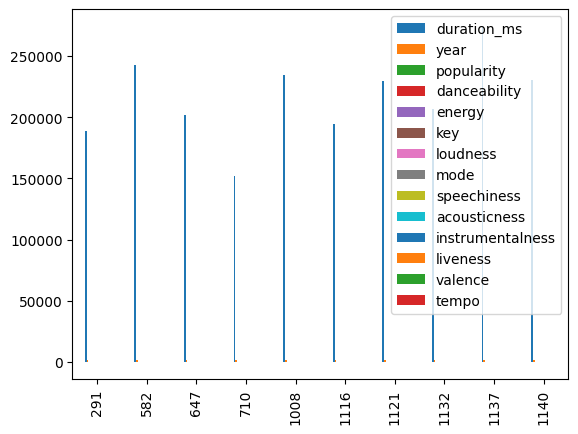

In [50]:
year12.plot(kind="bar")

Extracting Energy Values

In [51]:
X = list(df.loc[:, "energy"])[:10]
y = list(df.loc[:, "song"])[:10]

dentify top-performing songs. and check their poplarity ling graph show clrealy

In [56]:
fig=px.line(df.sort_values(by='popularity',ascending=False).head(25),x='song',y='popularity',hover_data=['artist'],color_discrete_sequence=['green'],markers=True,title='<b> Top 25 songs in Spotify')
fig.show()

What the Code Does
1. df.sort_values(by='popularity', ascending=False)

This sorts the dataset by the popularity column in descending order.

Songs with the highest popularity scores appear first.
Spotify popularity scores usually range from 0 to 100.

Example:

A song with popularity 90 is considered more popular than a song with popularity 60.
2. .head(25)

This selects the top 25 most popular songs after sorting.

.head(25)

This is done to:

Focus on the most popular songs only
Avoid overcrowding the chart
Make visualization easier to read
3. px.line()

plotly.express.line() creates a line chart.

x='song' → song names appear on the x-axis
y='popularity' → popularity scores appear on the y-axis

The line connects popularity values across songs.

4. hover_data=['artist']

When the user moves the mouse over a point, the artist name is displayed.

This improves interactivity and gives more information without cluttering the graph.

5. color_discrete_sequence=['green']

This sets the line color to green for better visual appearance.

6. markers=True

This adds markers (dots) on each song point.

Markers help:

Identify exact song positions
Make comparisons easier
Improve readability
7. title

Adds the chart title:

'<b> Top 25 songs in Spotify'

<b> makes the title bold.

8. fig.show()

Displays the final interactive chart.

Why This Code Is Used

This visualization is used to analyze and compare the most popular songs in the dataset.

Main Purposes
1. Identify Top Songs

It helps quickly determine:

Which songs are the most popular
How popularity differs among top tracks
2. Compare Popularity Scores

The line chart makes it easy to compare:

Small differences between songs
Songs with extremely high popularity
3. Detect Trends

The visualization can reveal:

Whether popularity drops gradually or sharply
If a few songs dominate the rankings

In [57]:
fig=px.line(df.sort_values(by='popularity',ascending=False).head(25),x='song',y='year',hover_data=['artist'],color_discrete_sequence=['green'],markers=True,title='<b> Top 25 songs in Spotify')
fig.show()

In [59]:
df.info


<bound method DataFrame.info of               artist                                    song  duration_ms  \
0     Britney Spears                  Oops!...I Did It Again       211160   
1          blink-182                    All The Small Things       167066   
2         Faith Hill                                 Breathe       250546   
3           Bon Jovi                            It's My Life       224493   
4             *NSYNC                             Bye Bye Bye       200560   
...              ...                                     ...          ...   
1995  Jonas Brothers                                  Sucker       181026   
1996    Taylor Swift                            Cruel Summer       178426   
1997    Blanco Brown                              The Git Up       200593   
1998       Sam Smith  Dancing With A Stranger (with Normani)       171029   
1999     Post Malone                                 Circles       215280   

      explicit  year  popularity  danceabil

In [62]:
genre = df[["genre"]]

genre = pd.get_dummies(genre, drop_first=True).astype(int)

genre.head()

,"genre_Folk/Acoustic, pop","genre_Folk/Acoustic, rock","genre_Folk/Acoustic, rock, pop",genre_R&B,"genre_World/Traditional, Folk/Acoustic","genre_World/Traditional, hip hop","genre_World/Traditional, pop","genre_World/Traditional, pop, Folk/Acoustic","genre_World/Traditional, rock","genre_World/Traditional, rock, pop",...,"genre_rock, blues","genre_rock, blues, latin","genre_rock, classical","genre_rock, easy listening","genre_rock, metal","genre_rock, pop","genre_rock, pop, Dance/Electronic","genre_rock, pop, metal","genre_rock, pop, metal, Dance/Electronic",genre_set()
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In this code we change categorical text valu to integer value throgh one hot coding

In [65]:
import pandas as pd

# remove spaces from column names
df.columns = df.columns.str.strip()

# convert categorical column to numeric
artist = pd.get_dummies(df[['artist']], drop_first=True).astype(int)

artist.head()

,artist_112,artist_2 Chainz,artist_21 Savage,artist_2Pac,artist_3 Doors Down,artist_3LW,artist_3OH!3,artist_5 Seconds of Summer,artist_50 Cent,artist_6ix9ine,...,artist_alt-J,artist_benny blanco,artist_blackbear,artist_blink-182,artist_fun.,artist_girl in red,artist_iann dior,artist_iio,artist_t.A.T.u.,artist_will.i.am
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#The dataset shows that:

Most music features are relatively independent.
Strongest relationships exist between:
energy and loudness
energy and acousticness
danceability and valence
Popularity is not strongly determined by audio features alone.
populirty of song/genre yearly changed

Overall, the dataset appears well-structured for:

music recommendation systems
clustering songs
mood analysis